# total mensual de viajeros internacionales



## 1. Importación de librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import (
    ExponentialSmoothing,
    Holt,
    SimpleExpSmoothing,
)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

pd.set_option("display.max_columns", None)


In [2]:
ARCHIVO = Path(
    "Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx"
)

if not ARCHIVO.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo: {ARCHIVO.resolve()}\n"
        "Coloque el Excel en la misma carpeta o cambie la ruta."
    )

df = pd.read_excel(ARCHIVO)

print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

df.head(10)

Dimensiones del dataset: (161036, 13)

Columnas:
['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región', 'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia', 'Tipo de Viajero', 'Viajero']


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0
5,2009,1,Ene,Aérea,01 La Aurora,Argentina,AMÉRICA DEL SUR,América Del Sur y el Caribe,AMÉRICA DEL SUR,03 SUDAMÉRICA,Suramérica,Turista,685.0
6,2009,1,Ene,Aérea,01 La Aurora,Australia,OCEANÍA,Oceanía,AUSTRALASIA,06 RESTO DEL MUNDO,Resto del Mundo,Turista,204.0
7,2009,1,Ene,Aérea,01 La Aurora,Austria,EUROPA,Europa,EUROPA OCCIDENTAL,08 OTROS,Europa,Turista,85.0
8,2009,1,Ene,Aérea,01 La Aurora,Bahamas,OTROS CARIBEÑOS,América Del Sur y el Caribe,EL CARIBE,08 OTROS,Resto del Mundo,Turista,4.0
9,2009,1,Ene,Aérea,01 La Aurora,Bangladesh,OTROS ASIA,Asia,ASIA MERIDIONAL,08 OTROS,Resto del Mundo,Turista,1.0


## 3. Validación y preparación de variables

In [3]:
columnas_requeridas = {"Año", "Mes cod", "Viajero"}
faltantes = columnas_requeridas - set(df.columns)

if faltantes:
    raise KeyError(
        "Faltan columnas requeridas: " + ", ".join(sorted(faltantes))
    )

df["Año"] = pd.to_numeric(df["Año"], errors="coerce")
df["Mes cod"] = pd.to_numeric(df["Mes cod"], errors="coerce")
df["Viajero"] = pd.to_numeric(df["Viajero"], errors="coerce")

df["Fecha"] = pd.to_datetime(
    {
        "year": df["Año"],
        "month": df["Mes cod"],
        "day": 1
    },
    errors="coerce"
)

print("Fechas inválidas:", df["Fecha"].isna().sum())
print("Valores inválidos en Viajero:", df["Viajero"].isna().sum())
print("Fecha mínima:", df["Fecha"].min())
print("Fecha máxima:", df["Fecha"].max())

Fechas inválidas: 0
Valores inválidos en Viajero: 0
Fecha mínima: 2009-01-01 00:00:00
Fecha máxima: 2026-06-01 00:00:00


In [4]:
serie_total = (
    df.dropna(subset=["Fecha", "Viajero"])
      .groupby("Fecha")["Viajero"]
      .sum()
      .sort_index()
      .asfreq("MS")
)

serie_total.name = "Total_mensual_viajeros"

print("Inicio:", serie_total.index.min())
print("Fin:", serie_total.index.max())
print("Frecuencia:", serie_total.index.freqstr)
print("Número de observaciones:", len(serie_total))
print("Meses faltantes:", serie_total.isna().sum())

serie_total.head()

Inicio: 2009-01-01 00:00:00
Fin: 2026-06-01 00:00:00
Frecuencia: MS
Número de observaciones: 210
Meses faltantes: 0


Fecha
2009-01-01    183505.590535
2009-02-01    149426.253908
2009-03-01    174237.227095
2009-04-01    182842.489917
2009-05-01    133194.667651
Freq: MS, Name: Total_mensual_viajeros, dtype: float64

In [5]:
if serie_total.isna().any():
    print("Meses faltantes encontrados:")
    display(serie_total[serie_total.isna()].to_frame())
else:
    print("la serie tiene todos los meses completos, no hay meses faltantes.")

la serie tiene todos los meses completos, no hay meses faltantes.


In [6]:
estadisticas = serie_total.describe().to_frame("Valor")
estadisticas

,Valor
count,210.000000
mean,248990.176637
std,100744.492958
min,9779.000000
25%,184592.862436
50%,250393.500000
75%,315372.811698
max,526190.000000


## 6. Gráfica de la serie

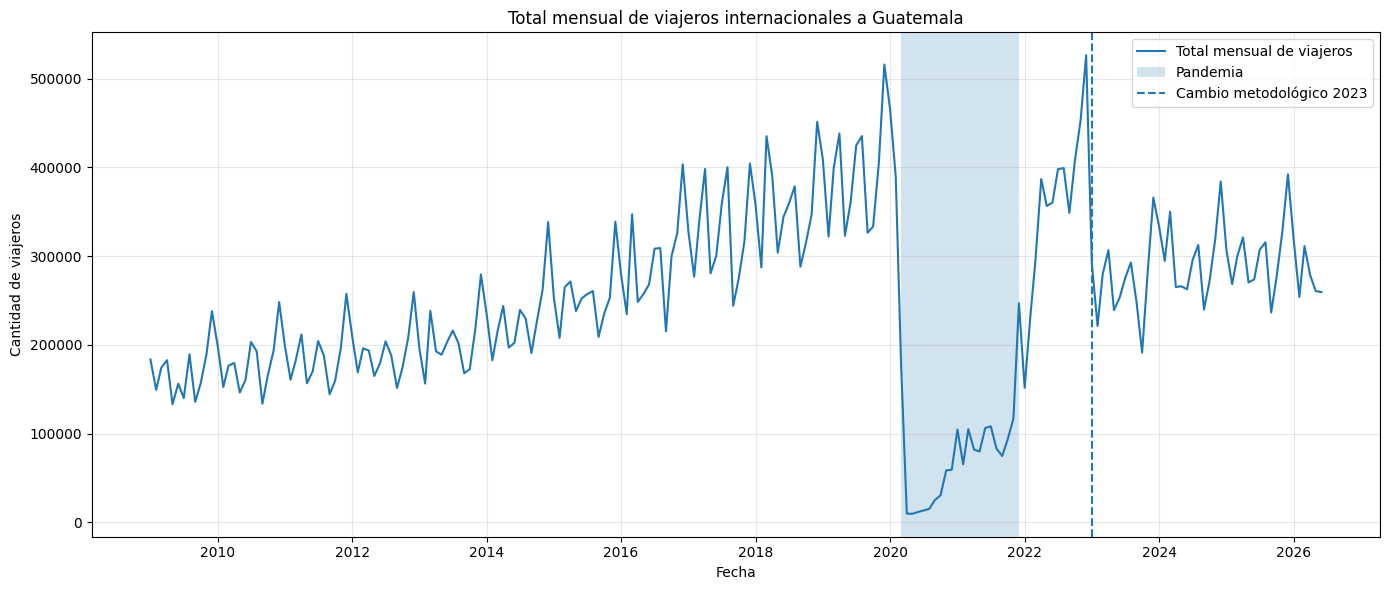

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(
    serie_total.index,
    serie_total,
    label="Total mensual de viajeros"
)

plt.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-12-01"),
    alpha=0.2,
    label="Pandemia"
)

plt.axvline(
    pd.Timestamp("2023-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="Cambio metodológico 2023"
)

plt.title("Total mensual de viajeros internacionales a Guatemala")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Media móvil de 12 meses

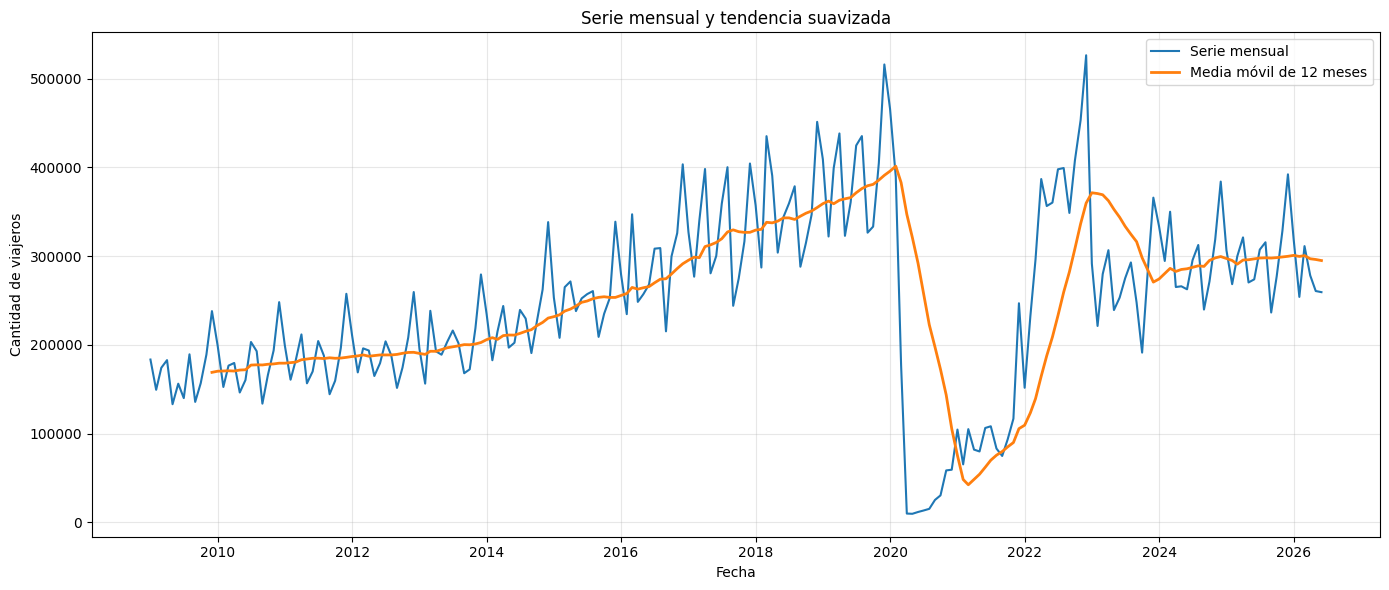

In [8]:
media_movil_12 = serie_total.rolling(12).mean()

plt.figure(figsize=(14, 6))
plt.plot(serie_total.index, serie_total, label="Serie mensual")
plt.plot(
    media_movil_12.index,
    media_movil_12,
    linewidth=2,
    label="Media móvil de 12 meses"
)
plt.title("Serie mensual y tendencia suavizada")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Descomposición de la serie

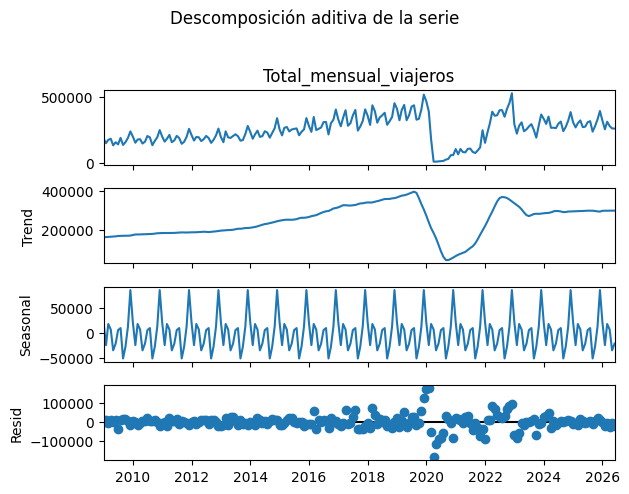

In [9]:
descomposicion_aditiva = seasonal_decompose(
    serie_total,
    model="additive",
    period=12,
    extrapolate_trend="freq"
)

descomposicion_aditiva.plot()
plt.suptitle("Descomposición aditiva de la serie", y=1.02)
plt.tight_layout()
plt.show()

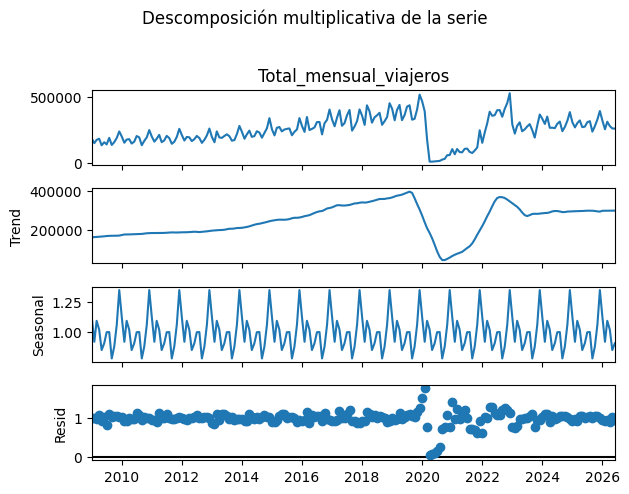

In [10]:
if (serie_total > 0).all():
    descomposicion_multiplicativa = seasonal_decompose(
        serie_total,
        model="multiplicative",
        period=12,
        extrapolate_trend="freq"
    )

    descomposicion_multiplicativa.plot()
    plt.suptitle("Descomposición multiplicativa de la serie", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(
        "No se realizó la descomposición multiplicativa "
        "porque la serie contiene ceros o valores negativos."
    )

## en varianza


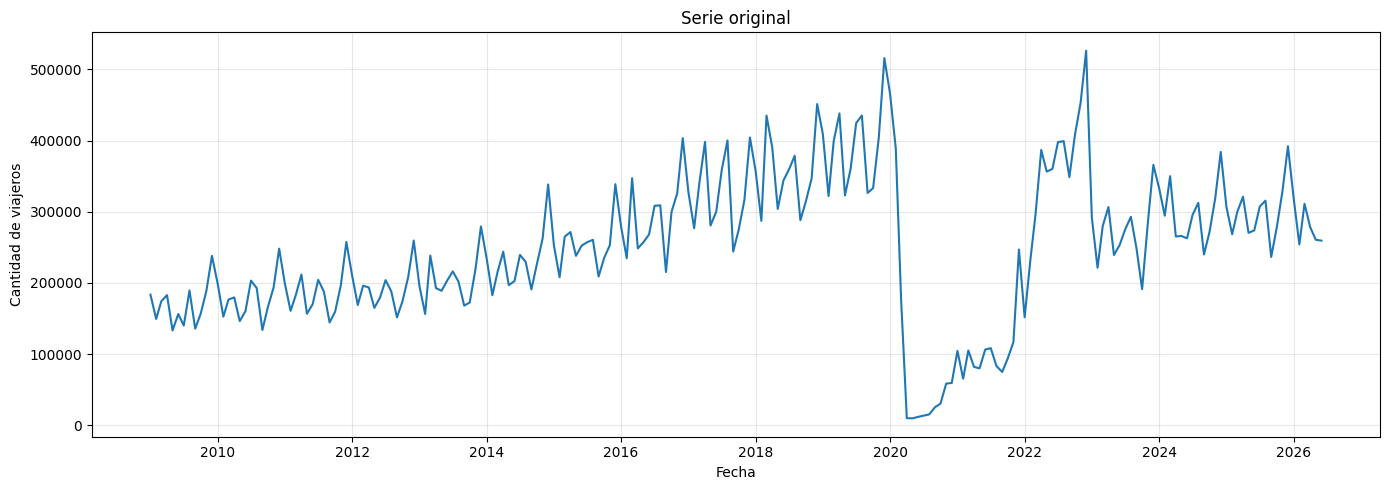

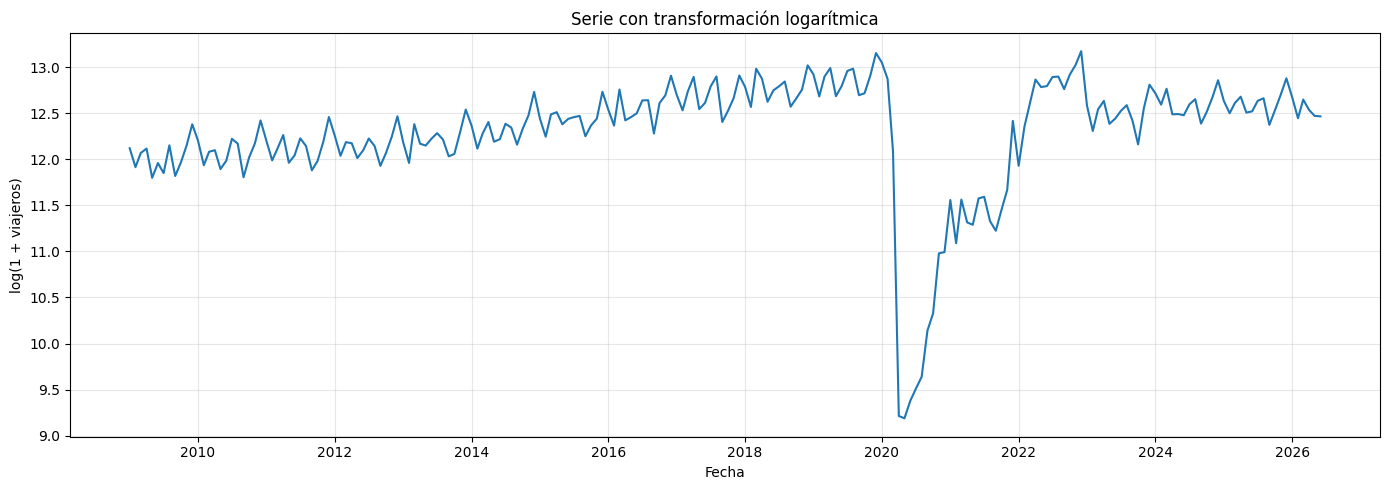

In [11]:
serie_log = np.log1p(serie_total)

plt.figure(figsize=(14, 5))
plt.plot(serie_total.index, serie_total, label="Serie original")
plt.title("Serie original")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(serie_log.index, serie_log, label="Serie log(1+x)")
plt.title("Serie con transformación logarítmica")
plt.xlabel("Fecha")
plt.ylabel("log(1 + viajeros)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()